# VGG: Deep Networks with Uniform 3×3 Filters (and the Cost of Simplicity)

## Introduction

**VGG** (Simonyan & Zisserman, 2014) proved that **depth matters more than filter size**. Its key insight: stack small 3×3 filters deeply instead of using large filters.

**Core principle:**

Two 3×3 convs = same receptive field as one 5×5 conv, but:
- **Fewer parameters** (2×9 = 18 vs 25)
- **More non-linearity** (2 ReLU layers vs 1)
- **Better feature learning**

**What we'll explore:**

- Why uniform 3×3 architecture is elegant and scalable
- Train VGG-11 on CIFAR-10 and compare to AlexNet
- Calculate the parameter savings from small filters
- **Identify VGG's own problems** that motivated Inception

**Why this matters:**

VGG showed that **simplicity scales**. One design rule (3×3 everywhere) enabled systematic depth exploration. But it also revealed that brute-force depth has costs: computational expense and massive FC layers.

## 1. Setup

### Import libraries

### Set random seed for reproducibility

In [ ]:
from aiml_notebooks import get_device, set_seed

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. Recap: AlexNet's Inefficiencies

Before diving into VGG, let's recall what we need to improve:

| AlexNet Problem | Impact |
|-----------------|--------|
| **Large filters (11×11, 5×5)** | Parameter waste, fewer non-linearities |
| **Heterogeneous design** | Hard to scale systematically |
| **No clear depth strategy** | Unclear how to go deeper |
| **FC layers dominate** | Most parameters, overfitting risk |

VGG solves the **first three** with one elegant principle: **3×3 everywhere**.

## 3. VGG's Key Insight: Stacked Small Filters

### Receptive Field Analysis

Let's prove that stacked 3×3 filters are equivalent to larger filters in receptive field but superior in every other way.

In [4]:
print("Receptive Field Equivalence:\n")
print("One 5×5 conv:")
print("  Receptive field: 5×5")
print("  Parameters (64 channels): 64 × 64 × 5 × 5 = 102,400")
print("  ReLU layers: 1")
print("\nTwo 3×3 convs:")
print("  Receptive field: 3 + (3-1) = 5×5 ✓ (same!)")
print("  Parameters: 2 × (64 × 64 × 3 × 3) = 73,728")
print("  ReLU layers: 2")
print("  Parameter savings: 28%")
print("\nOne 7×7 conv:")
print("  Receptive field: 7×7")
print("  Parameters: 64 × 64 × 7 × 7 = 200,704")
print("\nThree 3×3 convs:")
print("  Receptive field: 3 + (3-1) + (3-1) = 7×7 ✓ (same!)")
print("  Parameters: 3 × (64 × 64 × 3 × 3) = 110,592")
print("  ReLU layers: 3")
print("  Parameter savings: 45%")
print("\n✅ VGG's principle: Stack 3×3 filters for same receptive field with:")
print("   • Fewer parameters")
print("   • More non-linearity (more ReLU layers)")
print("   • Better feature discrimination")

Receptive Field Equivalence:

One 5×5 conv:
  Receptive field: 5×5
  Parameters (64 channels): 64 × 64 × 5 × 5 = 102,400
  ReLU layers: 1

Two 3×3 convs:
  Receptive field: 3 + (3-1) = 5×5 ✓ (same!)
  Parameters: 2 × (64 × 64 × 3 × 3) = 73,728
  ReLU layers: 2
  Parameter savings: 28%

One 7×7 conv:
  Receptive field: 7×7
  Parameters: 64 × 64 × 7 × 7 = 200,704

Three 3×3 convs:
  Receptive field: 3 + (3-1) + (3-1) = 7×7 ✓ (same!)
  Parameters: 3 × (64 × 64 × 3 × 3) = 110,592
  ReLU layers: 3
  Parameter savings: 45%

✅ VGG's principle: Stack 3×3 filters for same receptive field with:
   • Fewer parameters
   • More non-linearity (more ReLU layers)
   • Better feature discrimination


### Visualize receptive field growth

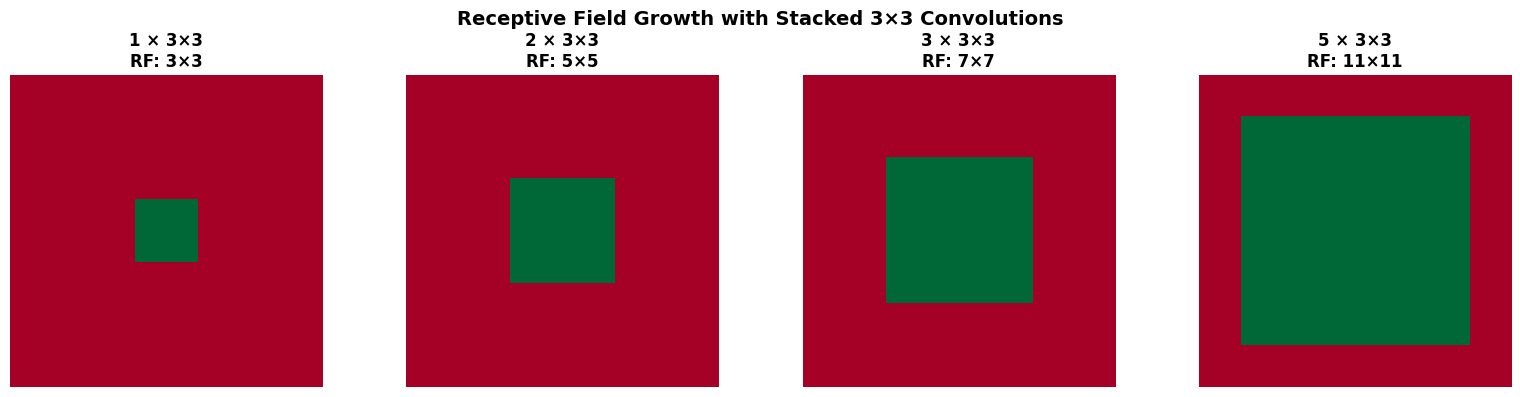


💡 Key insight: AlexNet's 11×11 first layer = 5 stacked 3×3 layers!
   But stacking gives you 5× more non-linearity.


In [5]:
# Visualize how receptive field grows with stacked 3×3 filters
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Create grids showing receptive field
configs = [
    (3, '1 × 3×3\nRF: 3×3'),
    (5, '2 × 3×3\nRF: 5×5'),
    (7, '3 × 3×3\nRF: 7×7'),
    (11, '5 × 3×3\nRF: 11×11')
]

for ax, (size, title) in zip(axes, configs):
    grid = np.zeros((15, 15))
    center = 7
    half = size // 2
    grid[center-half:center+half+1, center-half:center+half+1] = 1
    
    ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    ax.grid(True, which='both', color='black', linewidth=0.5, alpha=0.3)

plt.suptitle('Receptive Field Growth with Stacked 3×3 Convolutions', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key insight: AlexNet's 11×11 first layer = 5 stacked 3×3 layers!")
print("   But stacking gives you 5× more non-linearity.")

## 4. Dataset Preparation

### Define data transforms

In [ ]:
from torchvision import datasets, transforms

In [6]:
# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Load CIFAR-10 dataset

In [7]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


### Create data loaders

In [ ]:
from torch.utils.data import DataLoader

In [8]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## 5. VGG Architecture

### Original VGG Family (2014)

VGG explored systematic depth with uniform 3×3 convolutions:

- **VGG-11**: 8 conv layers + 3 FC (simplest)
- **VGG-13**: 10 conv layers + 3 FC
- **VGG-16**: 13 conv layers + 3 FC (most popular)
- **VGG-19**: 16 conv layers + 3 FC (deepest)

**Design principles:**
1. All conv filters are **3×3** with stride 1, padding 1
2. MaxPool **2×2** with stride 2 (halves spatial dimensions)
3. Channels **double** after each pooling: 64 → 128 → 256 → 512 → 512
4. **Very simple, uniform** architecture

### Our Implementation: VGG-11

We'll implement VGG-11 adapted for CIFAR-10 (32×32 images).

### Implement VGG-11

Notice the beautiful uniformity: 3×3 convs throughout, systematic doubling of channels.

In [9]:
class VGG11(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # VGG-11 configuration: [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
        # 'M' = MaxPool
        # All convs are 3×3 with padding=1 (keeps spatial size)
        
        self.features = nn.Sequential(
            # Block 1: 32×32 → 16×16, channels: 3 → 64
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 16×16 → 8×8, channels: 64 → 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 8×8 → 4×4, channels: 128 → 256 → 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4: 4×4 → 2×2, channels: 256 → 512 → 512
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 5: 2×2 → 1×1, channels: 512 → 512 → 512
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Classifier: 3 FC layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### Inspect the architecture

In [10]:
model = VGG11().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"VGG-11 Architecture:")
print(model)
print(f"\nParameter count:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Test forward pass
dummy_input = torch.randn(1, 3, 32, 32).to(device)
output = model(dummy_input)
print(f"\nOutput shape: {output.shape}")

VGG-11 Architecture:
VGG11(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)

### Compare to AlexNet

Let's see the improvements from uniform 3×3 architecture.

In [11]:
print("AlexNet vs VGG-11 Comparison:\n")
print(f"{'Metric':<30} {'AlexNet':<20} {'VGG-11':<20}")
print("-" * 70)
print(f"{'Convolutional layers':<30} {5:<20} {8:<20}")
print(f"{'Filter sizes':<30} {'Mixed (3×3)':<20} {'All 3×3 ✓':<20}")
print(f"{'Channel progression':<30} {'64→192→384→256':<20} {'64→128→256→512 ✓':<20}")
print(f"{'Design principle':<30} {'Heterogeneous':<20} {'Uniform ✓':<20}")
print(f"{'Depth scalability':<30} {'Unclear':<20} {'Systematic ✓':<20}")
print(f"{'Total parameters (CIFAR-10)':<30} {'~14.8M':<20} {f'~{total_params/1e6:.1f}M':<20}")
print("\n✅ VGG advantages:")
print("   • Uniform design (easy to understand and implement)")
print("   • Systematic depth scaling (just add more 3×3 layers)")
print("   • More non-linearity per receptive field")
print("   • Clearer design principles")

AlexNet vs VGG-11 Comparison:

Metric                         AlexNet              VGG-11              
----------------------------------------------------------------------
Convolutional layers           5                    8                   
Filter sizes                   Mixed (3×3)          All 3×3 ✓           
Channel progression            64→192→384→256       64→128→256→512 ✓    
Design principle               Heterogeneous        Uniform ✓           
Depth scalability              Unclear              Systematic ✓        
Total parameters (CIFAR-10)    ~14.8M               ~9.8M               

✅ VGG advantages:
   • Uniform design (easy to understand and implement)
   • Systematic depth scaling (just add more 3×3 layers)
   • More non-linearity per receptive field
   • Clearer design principles


## 6. Training

### Define training utilities

In [ ]:
from tqdm.auto import tqdm

In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{running_loss/len(pbar):.3f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate on test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(test_loader), 100. * correct / total

### Train the model

We'll train for 15 epochs to see VGG's performance.

In [13]:
# Initialize model
model = VGG11().to(device)

# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=3)

# Training history
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

# Training loop
epochs = 15
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(test_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Epoch 1/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.6969 | Train Acc: 33.53%
Test Loss: 1.4526 | Test Acc: 44.05%

Epoch 2/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.4349 | Train Acc: 85.84%
Test Loss: 0.5049 | Test Acc: 83.52%

Epoch 15/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.4112 | Train Acc: 86.55%
Test Loss: 0.4803 | Test Acc: 84.59%


## 7. Results and Analysis

### Plot training curves

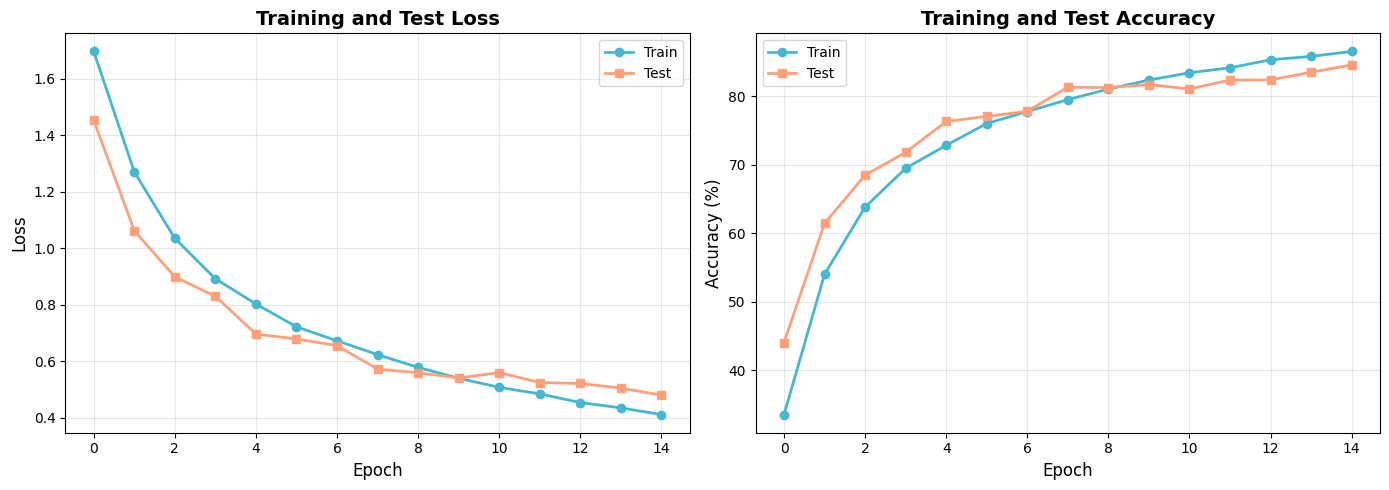


Final Results:
  Train Accuracy: 86.55%
  Test Accuracy: 84.59%
  Overfitting Gap: 1.96%


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train', marker='o', linewidth=2, color='#45B7D1')
ax1.plot(history['test_loss'], label='Test', marker='s', linewidth=2, color='#FFA07A')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train', marker='o', linewidth=2, color='#45B7D1')
ax2.plot(history['test_acc'], label='Test', marker='s', linewidth=2, color='#FFA07A')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  Overfitting Gap: {history['train_acc'][-1] - history['test_acc'][-1]:.2f}%")

## 8. VGG's Limitations

VGG proved that depth and uniformity work, but it revealed new problems.

### Limitation 1: Massive Parameter Count (Still FC-Dominated)

**Problem:** Despite efficient 3×3 filters, VGG is HUGE due to FC layers.

VGG-11 Parameter Distribution:
  Convolutional layers:  9,225,984 ( 94.6%)
  Fully-connected:         530,442 (  5.4%)
  Total:                 9,756,426

⚠️  Original VGG-16 on ImageNet: 138M parameters!
  • 90% of those are in FC layers
  • First FC layer alone: 7×7×512 × 4096 = 102M params
  • Makes model huge and slow

✅ Solution (later architectures): Global Average Pooling
  • Replace FC layers with average pooling
  • Drastically reduces parameters
  • Enables variable input sizes


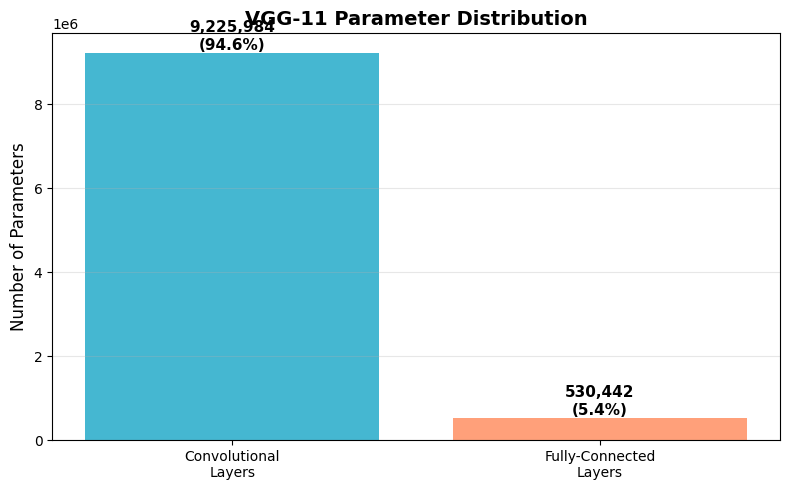

In [15]:
# Count parameters by layer type
conv_params = sum(p.numel() for name, p in model.named_parameters() 
                  if 'features' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() 
                if 'classifier' in name)
total = conv_params + fc_params

print(f"VGG-11 Parameter Distribution:")
print(f"  Convolutional layers: {conv_params:>10,} ({100*conv_params/total:>5.1f}%)")
print(f"  Fully-connected:      {fc_params:>10,} ({100*fc_params/total:>5.1f}%)")
print(f"  Total:                {total:>10,}")
print(f"\n⚠️  Original VGG-16 on ImageNet: 138M parameters!")
print(f"  • 90% of those are in FC layers")
print(f"  • First FC layer alone: 7×7×512 × 4096 = 102M params")
print(f"  • Makes model huge and slow")
print(f"\n✅ Solution (later architectures): Global Average Pooling")
print(f"  • Replace FC layers with average pooling")
print(f"  • Drastically reduces parameters")
print(f"  • Enables variable input sizes")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Convolutional\nLayers', 'Fully-Connected\nLayers'], 
              [conv_params, fc_params], 
              color=['#45B7D1', '#FFA07A'])
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('VGG-11 Parameter Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({100*height/total:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Limitation 2: Computational Inefficiency

**Problem:** Uniform depth means uniform computation everywhere - but not all layers need the same capacity!

In [16]:
print("Computational Cost Analysis:\n")
print("VGG processes every spatial location with the same depth.")
print("But do all features need the same receptive field?\n")
print("Consider an image with both:")
print("  • Fine details (eyes, text) → Need small receptive fields")
print("  • Large objects (cars, sky) → Need large receptive fields")
print("\nVGG's uniform approach:")
print("  ❌ All features pass through same # of 3×3 layers")
print("  ❌ No adaptation to different scales")
print("  ❌ Computationally wasteful")
print("\n✅ Inception's solution: Multi-scale parallel paths")
print("  • Run 1×1, 3×3, 5×5 convs in parallel")
print("  • Let the network learn which scale matters where")
print("  • More efficient than brute-force depth")

Computational Cost Analysis:

VGG processes every spatial location with the same depth.
But do all features need the same receptive field?

Consider an image with both:
  • Fine details (eyes, text) → Need small receptive fields
  • Large objects (cars, sky) → Need large receptive fields

VGG's uniform approach:
  ❌ All features pass through same # of 3×3 layers
  ❌ No adaptation to different scales
  ❌ Computationally wasteful

✅ Inception's solution: Multi-scale parallel paths
  • Run 1×1, 3×3, 5×5 convs in parallel
  • Let the network learn which scale matters where
  • More efficient than brute-force depth


### Limitation 3: Single-Scale Feature Extraction

**Problem:** Every VGG layer sees the world at one scale (3×3 windows).

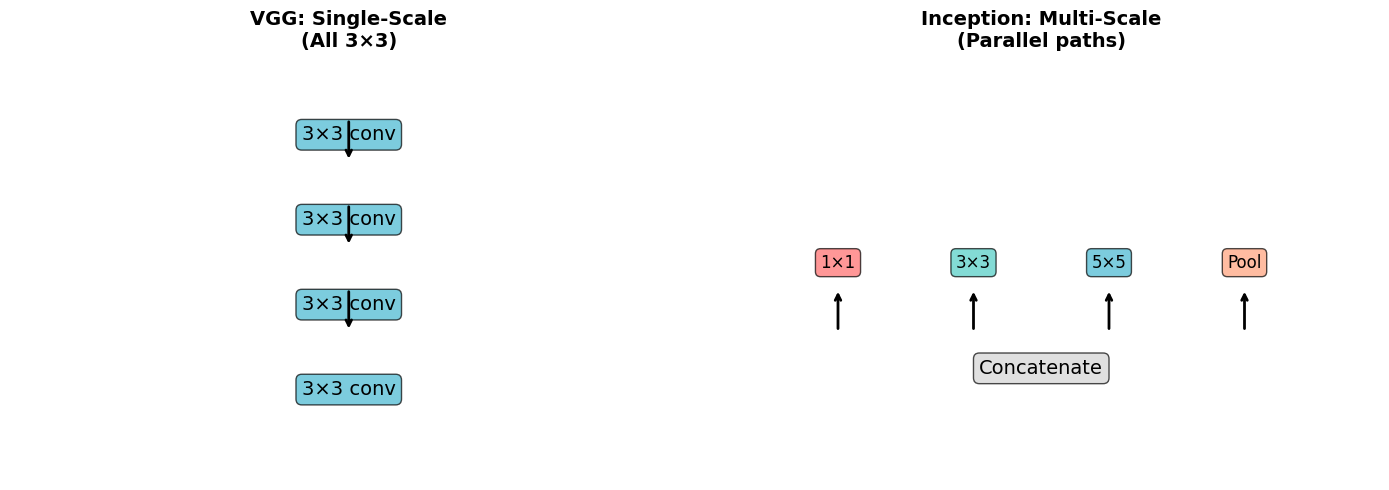


💡 VGG is like using only one tool for every job.
   Inception is like having multiple tools and choosing the best one.


In [17]:
# Visualize single vs multi-scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VGG: uniform 3×3
axes[0].text(0.5, 0.8, '3×3 conv', ha='center', fontsize=14, 
             bbox=dict(boxstyle='round', facecolor='#45B7D1', alpha=0.7))
axes[0].text(0.5, 0.6, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#45B7D1', alpha=0.7))
axes[0].text(0.5, 0.4, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#45B7D1', alpha=0.7))
axes[0].text(0.5, 0.2, '3×3 conv', ha='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='#45B7D1', alpha=0.7))
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_title('VGG: Single-Scale\n(All 3×3)', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[0].annotate('', xy=(0.5, 0.75), xytext=(0.5, 0.85),
                arrowprops=dict(arrowstyle='->', lw=2))
axes[0].annotate('', xy=(0.5, 0.55), xytext=(0.5, 0.65),
                arrowprops=dict(arrowstyle='->', lw=2))
axes[0].annotate('', xy=(0.5, 0.35), xytext=(0.5, 0.45),
                arrowprops=dict(arrowstyle='->', lw=2))

# Inception: multi-scale
y_pos = 0.5
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
labels = ['1×1', '3×3', '5×5', 'Pool']
x_positions = [0.2, 0.4, 0.6, 0.8]
for x, label, color in zip(x_positions, labels, colors):
    axes[1].text(x, y_pos, label, ha='center', fontsize=12,
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    axes[1].annotate('', xy=(x, y_pos-0.05), xytext=(x, y_pos-0.15),
                    arrowprops=dict(arrowstyle='->', lw=2))
axes[1].text(0.5, 0.25, 'Concatenate', ha='center', fontsize=14,
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Inception: Multi-Scale\n(Parallel paths)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n💡 VGG is like using only one tool for every job.")
print("   Inception is like having multiple tools and choosing the best one.")

### Limitation 4: Memory Consumption

**Problem:** Deep uniform networks require storing activations for every layer during backprop.

In [18]:
print("Memory Cost During Training (batch size 128):\n")
print("Activations must be stored for backprop:")
print("  Block 1 (32×32×64):   128 × 32 × 32 × 64  = 8.4M values")
print("  Block 2 (16×16×128):  128 × 16 × 16 × 128 = 4.2M values")
print("  Block 3 (8×8×256):    128 × 8 × 8 × 256   = 2.1M values")
print("  Block 4 (4×4×512):    128 × 4 × 4 × 512   = 1.0M values")
print("  Block 5 (2×2×512):    128 × 2 × 2 × 512   = 0.3M values")
print("\n  Total: ~16M float32 values = ~64 MB just for activations!")
print("  (And this is for tiny 32×32 images)")
print("\n  Original VGG-16 on 224×224 ImageNet:")
print("    ~96 MB per image")
print("    Batch of 32 = 3 GB memory!")
print("\n⚠️  This limits batch size and training speed.")

Memory Cost During Training (batch size 128):

Activations must be stored for backprop:
  Block 1 (32×32×64):   128 × 32 × 32 × 64  = 8.4M values
  Block 2 (16×16×128):  128 × 16 × 16 × 128 = 4.2M values
  Block 3 (8×8×256):    128 × 8 × 8 × 256   = 2.1M values
  Block 4 (4×4×512):    128 × 4 × 4 × 512   = 1.0M values
  Block 5 (2×2×512):    128 × 2 × 2 × 512   = 0.3M values

  Total: ~16M float32 values = ~64 MB just for activations!
  (And this is for tiny 32×32 images)

  Original VGG-16 on 224×224 ImageNet:
    ~96 MB per image
    Batch of 32 = 3 GB memory!

⚠️  This limits batch size and training speed.


## 9. Summary: VGG's Contribution and Inception's Innovations

### What VGG Got Right ✅

| Innovation | Impact |
|------------|--------|
| **Uniform 3×3 filters** | Simple, scalable, parameter-efficient |
| **Systematic depth** | Clear path to go deeper (VGG-11/13/16/19) |
| **Stacked small filters** | Same receptive field, more non-linearity |
| **Elegant design** | One simple rule instead of many hyperparameters |

**Result:** Showed that uniform, deep architectures outperform heterogeneous designs. Established 3×3 as the standard conv filter size.

---

### What Inception Improved 🎯

| VGG Problem | Inception Solution |
|-------------|--------------------|
| **FC layers dominate** | Global Average Pooling (no FC layers!) |
| **Single-scale features** | Multi-scale parallel convolutions (1×1, 3×3, 5×5) |
| **Uniform computation** | 1×1 bottleneck layers reduce computation |
| **Massive parameters** | Efficient design: 5M params vs VGG's 138M |

---

### The Evolution So Far

```
LeNet (1998):
  ❌ Too shallow, too few filters
  
AlexNet (2012):
  ✅ Depth + capacity + ReLU + Dropout
  ❌ Large filters, heterogeneous design
  
VGG (2014):
  ✅ Uniform 3×3 filters, systematic depth
  ❌ Parameter explosion, single-scale, FC-heavy
  
Inception (2014):
  ✅ Multi-scale, efficient, no FC layers
  ✅ 5M params, better accuracy than VGG-19
```

---

### Key Insights

1. **VGG proved uniformity works** - One design rule beats ad-hoc choices
2. **But uniformity can be wasteful** - Not all features need the same treatment
3. **Multi-scale is natural** - Real images have features at many scales
4. **FC layers are a bottleneck** - Most parameters, limited flexibility

---

### What's Next?

In the **Inception notebook**, we'll see how:
- **Parallel multi-scale convolutions** capture features at different scales
- **1×1 bottleneck layers** dramatically reduce computation
- **Global Average Pooling** eliminates FC layers entirely
- **Network-in-Network** concepts enable auxiliary classifiers

And we'll discover Inception's limitations that led to ResNet!